# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [2]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

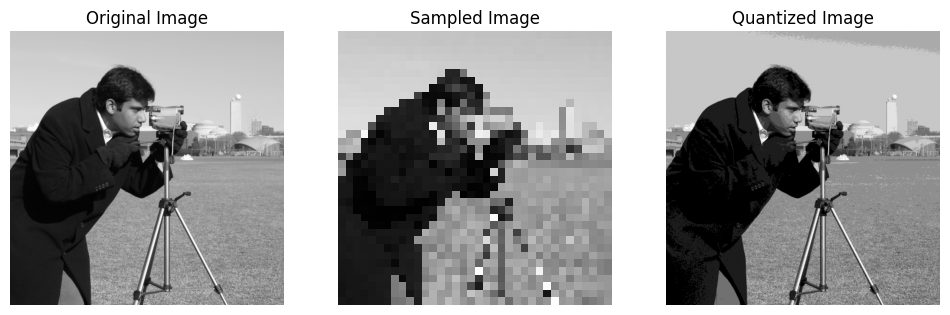

In [3]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

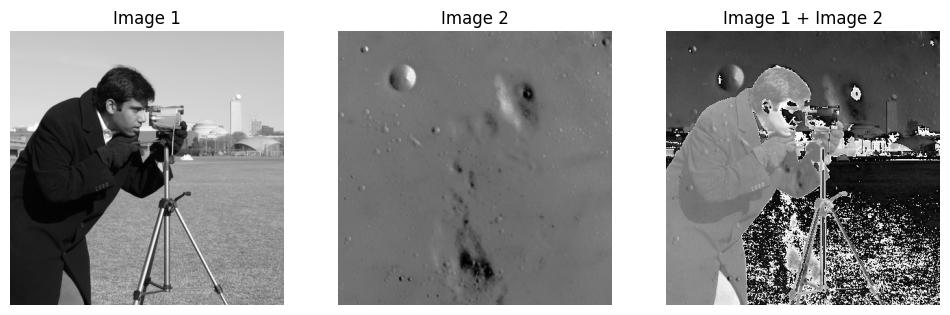

In [4]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

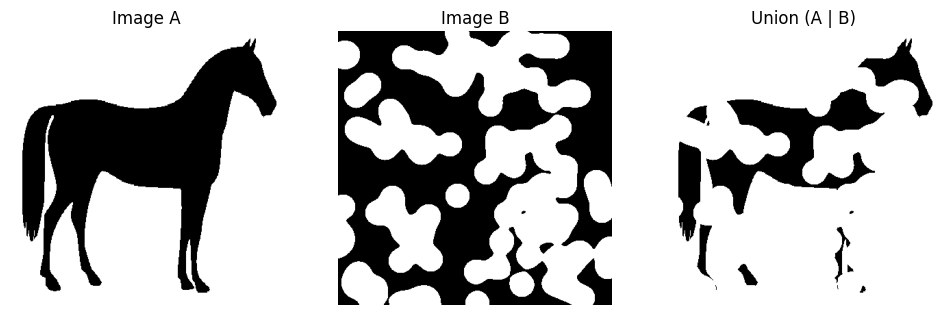

In [5]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

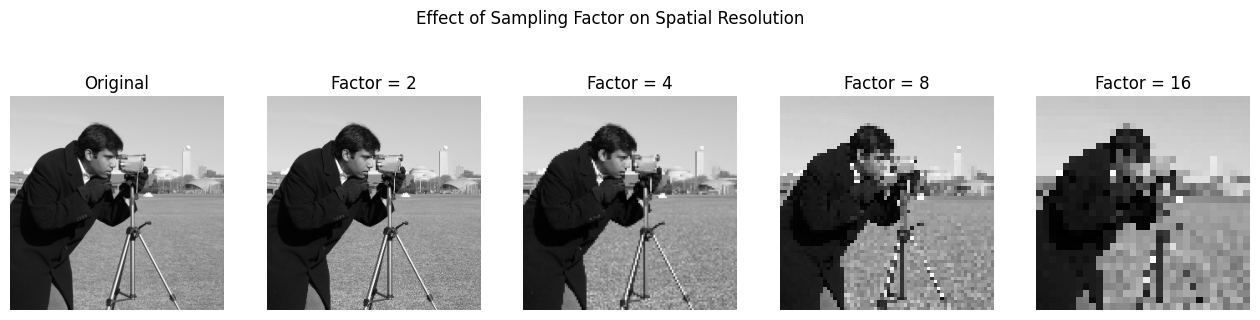

In [6]:
factors = [2, 4, 8, 16]

plt.figure(figsize=(16, 4))
plt.subplot(1, len(factors) + 1, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')
plt.axis('off')

for i, factor in enumerate(factors):
    sampled = sample_image(original_image, factor)
    plt.subplot(1, len(factors) + 1, i + 2)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'Factor = {factor}')
    plt.axis('off')

plt.suptitle('Effect of Sampling Factor on Spatial Resolution')
plt.show()


### 1b) Effect of quantization levels (intensity resolution)

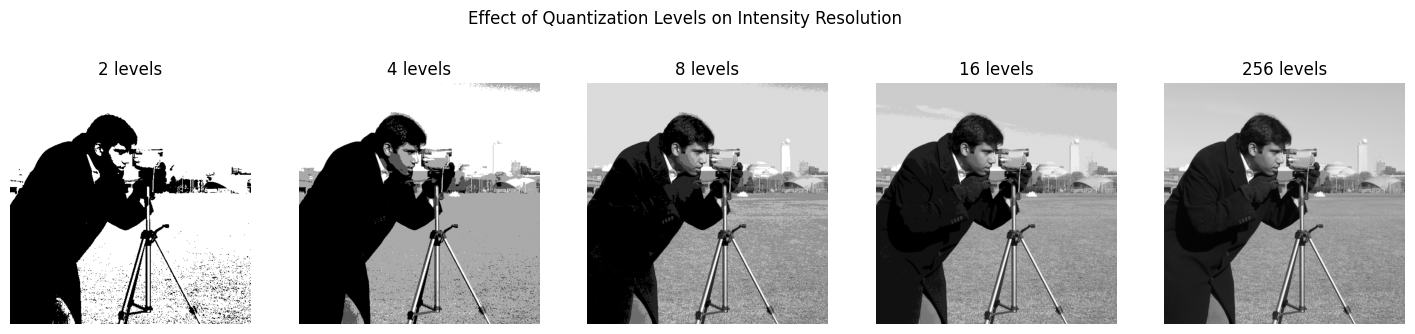

In [7]:
levels_list = [2, 4, 8, 16, 256]

plt.figure(figsize=(18, 4))
for i, levels in enumerate(levels_list):
    quantized = quantize_image(original_image, levels)
    plt.subplot(1, len(levels_list), i + 1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'{levels} levels')
    plt.axis('off')

plt.suptitle('Effect of Quantization Levels on Intensity Resolution')
plt.show()


---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

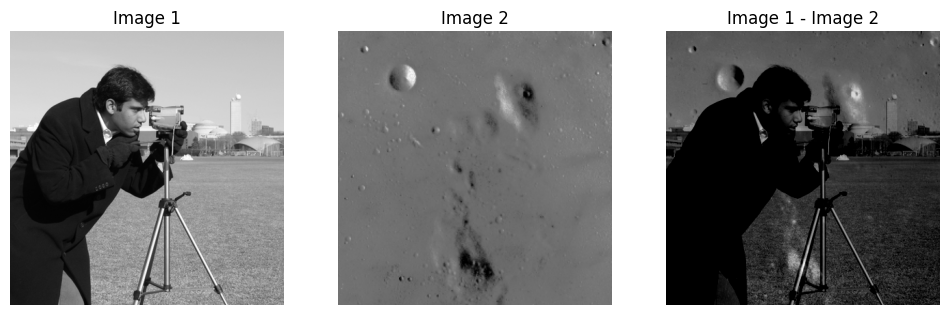

In [8]:
# Reuse im1arr (camera) and im2arr (moon) from Section 2
subtraction = cv2.subtract(im1arr, im2arr)
result_image_sub = Image.fromarray(subtraction)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_sub, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()


### 2b) Add image with constant value 175

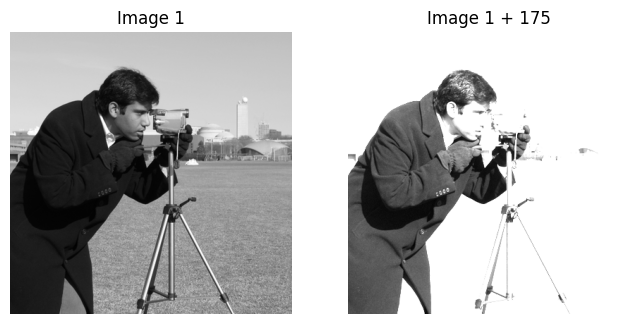

In [9]:
constant_value = 175
constant_array = np.full(im1arr.shape, constant_value, dtype=np.uint8)

added_constant = cv2.add(im1arr, constant_array)
result_image_const = Image.fromarray(added_constant)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(result_image_const, cmap='gray'), plt.title('Image 1 + 175'), plt.axis('off')
plt.show()


### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

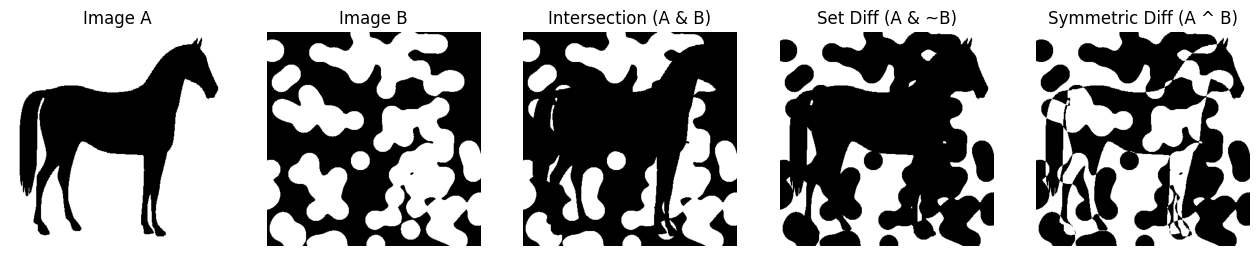

In [10]:
# Reuse im3arr (horse) and im4arr (binary blobs) from Section 3

intersection = im3arr & im4arr
set_difference = im3arr & ~im4arr
symmetric_difference = im3arr ^ im4arr

result_intersection = Image.fromarray(intersection)
result_set_diff = Image.fromarray(set_difference)
result_sym_diff = Image.fromarray(symmetric_difference)

plt.figure(figsize=(16, 4))
plt.subplot(1, 5, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 5, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 5, 3), plt.imshow(result_intersection, cmap='gray'), plt.title('Intersection (A & B)'), plt.axis('off')
plt.subplot(1, 5, 4), plt.imshow(result_set_diff, cmap='gray'), plt.title('Set Diff (A & ~B)'), plt.axis('off')
plt.subplot(1, 5, 5), plt.imshow(result_sym_diff, cmap='gray'), plt.title('Symmetric Diff (A ^ B)'), plt.axis('off')
plt.show()
